## Bath_dMFA_2026 Software 8 — Dependence between parameters (over time)

> Rick Lupton, University of Bath (June 2026)

In Notebook 7 we sampled the uncertain future drivers and propagated them
through the stock-driven model. When we sampled a parameter like the travel
demand `pCV`, we drew a **fresh random value for each year**: `rng.normal(pCV0,
0.10 * pCV0)` returns 36 independent numbers, one per year. We are implicitly
assuming that the error in 2040 is *independent* of the error in 2041.

Is that realistic? It depends on the reason for the error. If we are
systematically over- or under-estimating future travel demand, we are probably
wrong in the *same direction* for many years at once (they are not independent).
In this notebook we'll explore how much that matters for the results of the
uncertainty analysis.

The underlying model is exactly the same as Notebook 7; the differences are
entirely in how we sample the random parameter values.

This notebook has two main parts:

- **Section 1 — setup.** Reload the stock-driven model (nothing new).
- **Section 2 — independent vs shared across years.** Add two ways to sample the
  same parameter across years, and see their effect on model outputs.

## Setup

This is all the same as already seen in Notebook 7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.special import gamma

DATA = "../data/Bath_dMFA_2026_Software_Data.xlsx"
RESULTS2 = "../data/Bath_dMFA_2026_Software_2_Results.xlsx"

# Future scenario drivers (2025-2060), best-guess values:
P0 = pd.read_excel(DATA, sheet_name="Population", index_col=0).values[:, 0] * 1e6   # people
pCV0 = pd.read_excel(DATA, sheet_name="Passenger_km", index_col=0).values[:, 0]     # p-km per capita / yr
OR0 = pd.read_excel(DATA, sheet_name="Occupancy rate", index_col=0).values[:, 0]    # persons per car
IU0 = pd.read_excel(DATA, sheet_name="Kilometrage", index_col=0).values[35:, 0]     # km per vehicle / yr

BEVshare_cT = pd.read_excel(DATA, sheet_name="BEV_share", index_col=0).values        # (71, 2), %
life0 = pd.read_excel(DATA, sheet_name="Lifetime", index_col=0).values[0].astype(float)
I_c = pd.read_excel(DATA, sheet_name="New registration", index_col=0).values[:, 0]   # historic inflow

# Fixed historic fleet (1990-2024) from Notebook 2, used to initialise the projection:
HIST_S = np.zeros((71, 71, 2))
HIST_S[0:35, 0:35, 0] = pd.read_excel(RESULTS2, sheet_name="Stock_tc_gasoline", index_col=0).values
HIST_S[0:35, 0:35, 1] = pd.read_excel(RESULTS2, sheet_name="Stock_tc_BEVs", index_col=0).values
HIST_O = np.zeros((71, 71, 2))
HIST_O[0:35, 0:35, 0] = pd.read_excel(RESULTS2, sheet_name="Outflow_tc_gasoline", index_col=0).values
HIST_O[0:35, 0:35, 1] = pd.read_excel(RESULTS2, sheet_name="Outflow_tc_BEVs", index_col=0).values
HIST_IcT = np.zeros((71, 2))
HIST_IcT[0:35] = np.einsum("c,cT->cT", I_c, BEVshare_cT[0:35, :]) / 100

years_full = np.arange(1990, 2061)   # 71 years, for plotting

In [2]:
def lifetime_pdf(lifetime, sigma_frac, pdf_kind):
    """Discard probability by age (shape (2, 71)) for the two technologies."""
    ages = np.arange(71)
    tau = np.asarray(lifetime, float).reshape(2, 1)
    if pdf_kind == "normal":
        return scipy.stats.norm.pdf(ages, tau, sigma_frac * tau)
    elif pdf_kind == "weibull":
        shape = 2.0
        scale = tau / gamma(1 + 1 / shape)
        return scipy.stats.weibull_min.pdf(ages, shape, scale=scale)
    raise ValueError(f"unknown pdf_kind: {pdf_kind}")


def run_stock_driven_model(P_t, pCV_t, OR_t, IU_t, bev_share, lifetime, sigma_frac=0.3, pdf_kind="normal"):
    """Stock-driven projection (Notebook 3/7) over 1990-2060.

    Returns inflow_cT (71, 2), stock_tcT (71, 71, 2), outflow_tcT (71, 71, 2).
    """
    S_future = P_t * pCV_t / (OR_t * IU_t)           # required total fleet size, 2025-2060
    pdf = lifetime_pdf(lifetime, sigma_frac, pdf_kind)

    inflow_cT = HIST_IcT.copy()                      # start from the fixed historic fleet
    stock_tcT = HIST_S.copy()
    outflow_tcT = HIST_O.copy()

    for year in range(35, 71):                       # for all future years (2025-2060)
        stock_tcT[year, :, :] = stock_tcT[year - 1, :, :]
        for drivetech in range(2):
            leave = np.zeros(71)
            for age_cohort in range(year + 1):
                leave[age_cohort] = inflow_cT[age_cohort, drivetech] * pdf[drivetech, year - age_cohort]
            stock_tcT[year, :, drivetech] -= leave
            outflow_tcT[year, :, drivetech] += leave
        gap = S_future[year - 35] - stock_tcT[year, :, :].sum()   # shortfall vs the demand
        inflow_cT[year, :] = gap * bev_share[year, :] / 100       # new registrations fill the gap
        stock_tcT[year, year, :] = inflow_cT[year, :]

    return inflow_cT, stock_tcT, outflow_tcT

Run it once on the best-guess inputs to get deterministic trajectories to
compare against (again, the same as Notebook 7). 

In [3]:
inflow_cT, stock_tcT, outflow_tcT = run_stock_driven_model(P0, pCV0, OR0, IU0, BEVshare_cT, life0)
I_det = inflow_cT.sum(1)                        # total new registrations per year
O_det = outflow_tcT.sum(axis=(1, 2))           # total scrappage per year
Ocum_det = np.cumsum(O_det)                    # cumulative scrappage
print("Registrations in 2050:      ", f"{I_det[60]:11,.0f}")
print("Cumulative outflows to 2060:", f"{Ocum_det[-1]:11,.0f}")

Registrations in 2050:        11,105,983
Cumulative outflows to 2060: 598,376,348


## Section 2 — Independent vs shared errors across years

We'll focus here on a single uncertain parameter: the **travel demand** `pCV`
(passenger-km per capita per year). For simplicity, we'll keep all other
parameters fixed at their best-guess values, but in fact the same issues apply
to other parameters too.

For `pCV`, we'll now look at two different uncertainty models for the annual
parameter values: *independent errors* (each year's error is independent of the
others) and *systematic shared error* (all years are affected by the same
uncertainty). In both cases, the size of the uncertainty (the per-year spread)
will be the same. 

### Step 1 — two ways to sample the same parameter

Write two functions that each return a sampled `pCV_t` array (one value per
future year, the same shape as `pCV0`), perturbed with a 10 % coefficient of
variation, but in two different ways:

- `draw_pCV_independent` — use a new random factor for each year, so the errors
  are independent across years.
- `draw_pCV_shared` — draw a **single** random factor, which is applied to
  *every* year, so the whole trajectory shifts up or down together.

*Hint:* `rng.normal(1.0, cv)` gives one number; `rng.normal(1.0, cv,
size=pCV0.shape)` gives one per year. Multiply `pCV0` by the factor.

In [4]:
def draw_pCV_independent(rng, cv=0.10):
    """A fresh random factor for EACH year — errors independent across years."""
    return pCV0 * rng.normal(1.0, cv, size=pCV0.shape)


def draw_pCV_shared(rng, cv=0.10):
    """ONE random factor, applied to ALL years — errors fully shared across years."""
    return pCV0 * rng.normal(1.0, cv)

### Step 2 — look at some samples

First, test your draw functions and see what they return. Print one draw of
each: the independent one should be a *different* number every year; the shared
one should be the *same* number repeated down all years — and a *different*
repeated number on the next draw. 

In [5]:
rng = np.random.default_rng(20260801)

print("independent (factor vs best guess, first 6 years):", (draw_pCV_independent(rng) / pCV0)[:6].round(3))
print("shared      (factor vs best guess, first 6 years):", (draw_pCV_shared(rng) / pCV0)[:6].round(3))
print("shared, a second draw                            :", (draw_pCV_shared(rng) / pCV0)[:6].round(3))

independent (factor vs best guess, first 6 years): [0.933 0.819 0.868 0.839 1.108 0.922]
shared      (factor vs best guess, first 6 years): [1.013 1.013 1.013 1.013 1.013 1.013]
shared, a second draw                            : [0.877 0.877 0.877 0.877 0.877 0.877]


**Check your work:** the assertions below encode exactly that distinction —
every year scaled by the *same* factor for the shared draw, *different* factors
for the independent one. They should pass once your functions are right.

In [6]:
_ind = draw_pCV_independent(rng) / pCV0
_sh = draw_pCV_shared(rng) / pCV0
assert np.allclose(_sh, _sh[0]), "shared draw should scale EVERY year by the same factor"
assert not np.allclose(_ind, _ind[0]), "independent draw should scale each year DIFFERENTLY"
print("ok — the two samplers differ as intended")

ok — the two samplers differ as intended


> **Optional:** it would be nice to show the same thing visually — if you like,
> make a plot showing the baseline `pCV0` against year, and overlay it with
several samples from either `draw_pCV_independent` or `draw_pCV_shared`, to
show clearly how they produce different types of uncertainty.

### Step 3 — predict first

Before running anything, write down your predictions (no code):

1. The fan of **annual inflow** (new registrations): wider under independent or
   shared draws?
2. The fan of **cumulative outflow** (total end-of-life vehicles summed from
   2025): wider under independent or shared draws?
3. Do you expect the same answer to both? Why or why not?

Write your predictions/thoughts in the cell below.

### Step 4 — Monte Carlo sampling

The approach is the same as Notebook 7 — sample uncertain parameters, run the
model, collect the outputs of interest.

This time, though, to avoid repeating very similar code multiple times, we'll
use a helper function `run_ensemble`, outlined below. This function takes
another function as an input, and calls it to draw samples of `pCV`: by passing
in either of your two functions above, `draw_pCV_independent` or
`draw_pCV_shared`, we can reuse the Monte Carlo code but change the way the
sampling of the specific parameter is done.

Complete the parts of the function that decide what output quantities to record:
the total new registrations per year (inflow), and the **cumulative** total
outflow.

*Hint:* `inflow.sum(1)` totals over the two technologies; total outflow per year
is `outflow.sum(axis=(1, 2))`; `np.cumsum` turns that into a cumulative total. 

In [7]:
def run_ensemble(sample_pCV, rng, N=500, model=run_stock_driven_model):
    """
    Perturb only pCV (via sample_pCV) and collect per-year results over N runs.
    """
    # empty arrays to store outputs from each sample
    inflow_samples = np.zeros((N, 71))
    cumoutflow_samples = np.zeros((N, 71))
    for i in range(N):
        inflow, stock, outflow = model(P0, sample_pCV(rng), OR0, IU0, BEVshare_cT, life0)
        inflow_samples[i] = inflow.sum(1)
        cumoutflow_samples[i] = np.cumsum(outflow.sum(axis=(1, 2)))
    return inflow_samples, cumoutflow_samples

In [8]:
rng = np.random.default_rng(20260801)
ind_inflow, ind_cum = run_ensemble(draw_pCV_independent, rng)
sh_inflow, sh_cum = run_ensemble(draw_pCV_shared, rng)
print("ensembles done:", ind_inflow.shape)

ensembles done: (500, 71)


### Step 5 — the comparison

Here is code that plots fan-charts (the percentile bands, as in Notebooks 6–7) —
another helper function avoids some of the repetition. We plot the two
quantities of interest side by side, with the independent and shared fans on top
of each other.

Note that the deterministic value is also plotted on top -- important to make
sure that your Monte Carlo results are centred in a reasonable place!

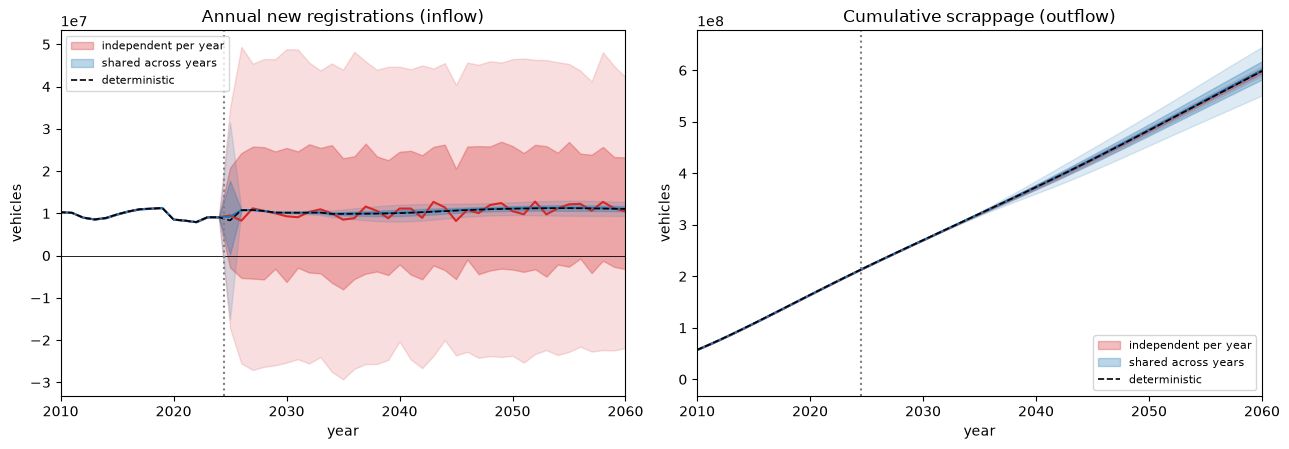

In [9]:
def plot_fan(ax, years, samples, color, label):
    p = np.percentile(samples, [5, 25, 50, 75, 95], axis=0)
    ax.fill_between(years, p[0], p[4], color=color, alpha=0.15)
    ax.fill_between(years, p[1], p[3], color=color, alpha=0.30, label=label)
    ax.plot(years, p[2], color=color, lw=1.5)


fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

plot_fan(ax[0], years_full, ind_inflow, "C3", "independent per year")
plot_fan(ax[0], years_full, sh_inflow, "C0", "shared across years")
ax[0].plot(years_full, I_det, "k--", lw=1.2, label="deterministic")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_title("Annual new registrations (inflow)")

plot_fan(ax[1], years_full, ind_cum, "C3", "independent per year")
plot_fan(ax[1], years_full, sh_cum, "C0", "shared across years")
ax[1].plot(years_full, Ocum_det, "k--", lw=1.2, label="deterministic")
ax[1].set_title("Cumulative scrappage (outflow)")

for a in ax:
    a.axvline(2024.5, color="grey", ls=":"); a.set_xlim(2010, 2060)
    a.set_xlabel("year"); a.set_ylabel("vehicles"); a.legend(fontsize=8)
fig.tight_layout();

What do you see?

- Which result (cumulative outflow, or 2060 registrations) shows the biggest
  difference between the shared/independent uncertainty models?

- Does the uncertainty in the output increase or decrease in each output when
  moving from the independent to shared uncertainty model?

Can you explain why?

> **Optional exercise:** You may find that you have negative inflow values
>   appearing in your results, which are probably unwanted physically. Can you
>   adapt the stock-driven model to fix this? Copy `run_stock_driven_model` from
>   Section 1 into a new cell below, rename it `run_model_no_negative_inflow`,
>   and make the fix.  Then rerun the sampling like this:
>
>   ```
>   fix_inflow, fix_cum = run_ensemble(draw_pCV_independent, rng, model=run_model_no_negative_inflow)
>   ```

In [10]:
# Explanation: that independent inflow fan dipping below zero is a red flag: a
# *negative* number of new registrations is impossible — you cannot un-register
# cars. The model happily produced it because, in a year when the random demand
# falls below the surviving fleet, the "gap" it fills goes negative.
#
# A more realistic model would say: in such a year you simply register **no** new
# cars and let the fleet age down on its own. That is a one-line change.
#
# *Hint:* `max(gap, 0.0)`, or `np.clip`.

In [11]:
def run_model_no_negative_inflow(P_t, pCV_t, OR_t, IU_t, bev_share, lifetime, sigma_frac=0.3, pdf_kind="normal"):
    """As run_stock_driven_model, but new registrations can never be negative."""
    S_future = P_t * pCV_t / (OR_t * IU_t)
    pdf = lifetime_pdf(lifetime, sigma_frac, pdf_kind)
    inflow_cT = HIST_IcT.copy(); stock_tcT = HIST_S.copy(); outflow_tcT = HIST_O.copy()
    for year in range(35, 71):
        stock_tcT[year, :, :] = stock_tcT[year - 1, :, :]
        for drivetech in range(2):
            leave = np.zeros(71)
            for age_cohort in range(year + 1):
                leave[age_cohort] = inflow_cT[age_cohort, drivetech] * pdf[drivetech, year - age_cohort]
            stock_tcT[year, :, drivetech] -= leave
            outflow_tcT[year, :, drivetech] += leave
        gap = S_future[year - 35] - stock_tcT[year, :, :].sum()
        gap = max(gap, 0.0)   # registrations can't be negative — floor the gap at zero
        inflow_cT[year, :] = gap * bev_share[year, :] / 100
        stock_tcT[year, year, :] = inflow_cT[year, :]
    return inflow_cT, stock_tcT, outflow_tcT

Re-run the independent ensemble with the corrected model and re-plot the
registrations. The negative inflows should be gone. 

fraction of negative 2050 registrations now: 0%


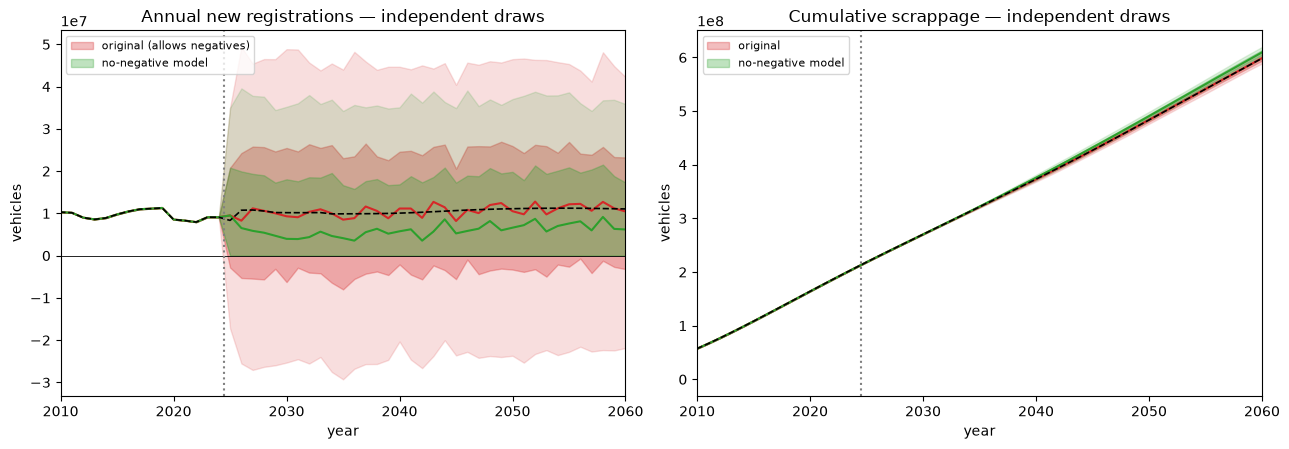

In [12]:
rng = np.random.default_rng(20260801)
fix_inflow, fix_cum = run_ensemble(draw_pCV_independent, rng, model=run_model_no_negative_inflow)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
plot_fan(ax[0], years_full, ind_inflow, "C3", "original (allows negatives)")
plot_fan(ax[0], years_full, fix_inflow, "C2", "no-negative model")
ax[0].plot(years_full, I_det, "k--", lw=1.2); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_title("Annual new registrations — independent draws")

plot_fan(ax[1], years_full, ind_cum, "C3", "original")
plot_fan(ax[1], years_full, fix_cum, "C2", "no-negative model")
ax[1].plot(years_full, Ocum_det, "k--", lw=1.2)
ax[1].set_title("Cumulative scrappage — independent draws")
for a in ax:
    a.axvline(2024.5, color="grey", ls=":"); a.set_xlim(2010, 2060)
    a.set_xlabel("year"); a.set_ylabel("vehicles"); a.legend(fontsize=8)
fig.tight_layout();

print(f"fraction of negative 2050 registrations now: {(fix_inflow[:, 60] < 0).mean():.0%}")

Even with this fix, the inflow uncertainty band is still much wider under
independent draws than under shared ones. The cumulative-outflow results are
hardly changed.

## Further exercises

We've focused on `pCV` but what about other parameters? Do they work in the same
way?

> **Optional exercise:** Try adapting your code to use shared uncertainty
    sampling for other parameters in the stock-driven model. Should each
    parameter have its own shared uncertainty value across years, or should
    multiple parameter share the same error?

The shared and independent uncertainty are two extreme ends of a spectrum; you
can also have uncertainty models that sit somewhere in between.

> **Optional exercise:** A simple way to produce less extreme behaviour is to split each year's error
> into a *common* part (shared by all years) and an *idiosyncratic* part
> (independent per year), mixed by a correlation parameter `rho`:
>
> `x_t = sqrt(rho) * z_common + sqrt(1 - rho) * z_t`
>
> where `z_common` is a single draw and `z_t` is one draw per year. At `rho = 0`
> this is the fully-independent case; at `rho = 1` it is the fully-shared case.
>
> Can you implement this sampler, and demonstrate that it can produce the same
  results as before, as well as intermediate behaviour? 

## Conclusions

The *marginal* uncertainty on a parameter (i.e. how wrong it might be in any one
year) is only part of the picture. We've seen in this notebook that the
dependence structure (e.g. whether errors are shared across years) can make a
big difference for some model outputs, but less difference for others.

In practice, we often don't know the true answer about dependence between
parameters, but you can still test different cases and see how it affects your
conclusions. 